✅ Plik /content/ecommerce.csv został wczytany pomyślnie.

🔹 Podgląd danych:


,Order_ID,Customer_ID,Category,Sales,Month
0,1,12,Home,60,Jan
1,2,15,Home,51,Jan
2,3,4,Home,400,Jan
3,4,14,Electronics,458,Jan
4,5,14,Home,323,Jan



🔹 Podstawowe statystyki:


,Order_ID,Customer_ID,Sales
count,100.000000,100.000000,100.000000
mean,50.500000,10.510000,264.300000
std,29.011492,5.895547,124.050617
min,1.000000,1.000000,51.000000
25%,25.750000,5.000000,172.250000
50%,50.500000,11.000000,277.000000
75%,75.250000,15.000000,354.750000
max,100.000000,19.000000,497.000000



🔹 Sprzedaż według kategorii:


,Sales
Category,
Clothing,9575
Electronics,9026
Home,7829


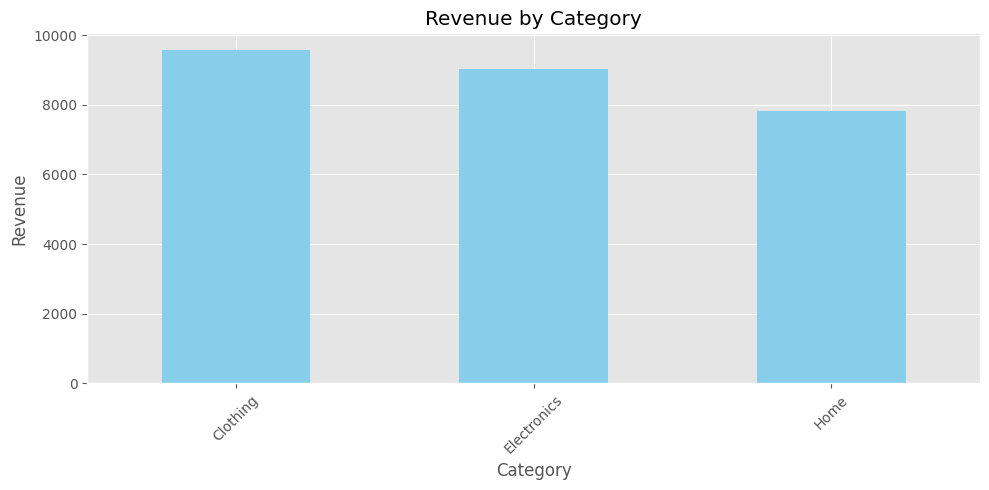

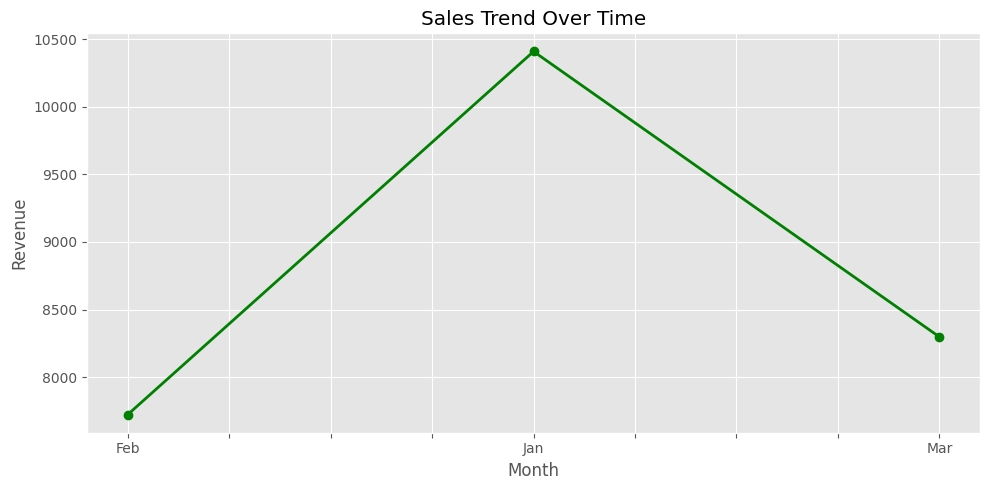


🤖 SYMULACJA AI CHAT:
Q: Jaki jest całkowity przychód? -> A: Całkowity przychód: 26,430.00
Q: Najlepsza kategoria? -> A: Najlepsza kategoria to: Clothing


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Ustawienie stylu wykresów
plt.style.use('ggplot')

# =========================
# 📂 KROK 1 — ŁADOWANIE DANYCH
# =========================

file_path = '/content/ecommerce.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"✅ Plik {file_path} został wczytany pomyślnie.\n")
else:
    print(f"❌ Błąd: Nie znaleziono pliku {file_path}. Sprawdź, czy plik znajduje się w folderze /content/.")
    # Zatrzymanie dalszego wykonywania jeśli brak pliku
    raise FileNotFoundError()

# =========================
# 📄 KROK 2 — PODGLĄD DANYCH
# =========================

print("🔹 Podgląd danych:")
display(df.head())

# =========================
# 📊 KROK 3 — STATYSTYKI
# =========================

print("\n🔹 Podstawowe statystyki:")
display(df.describe())

# =========================
# 📊 KROK 4 — ANALIZA KATEGORII
# =========================

if "Category" in df.columns and "Sales" in df.columns:
    category_data = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

    print("\n🔹 Sprzedaż według kategorii:")
    display(category_data)

    plt.figure(figsize=(10, 5))
    category_data.plot(kind="bar", color='skyblue')
    plt.title("Revenue by Category")
    plt.ylabel("Revenue")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# =========================
# 📈 KROK 5 — TRENDY
# =========================

if "Month" in df.columns and "Sales" in df.columns:
    # Opcjonalnie: sortowanie miesięcy jeśli są w formacie tekstowym
    trend_data = df.groupby("Month")["Sales"].sum()

    plt.figure(figsize=(10, 5))
    trend_data.plot(marker="o", color='green', linewidth=2)
    plt.title("Sales Trend Over Time")
    plt.xlabel("Month")
    plt.ylabel("Revenue")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# =========================
# 🤖 KROK 6 — FUNKCJA ZAPYTAŃ (AI CHAT)
# =========================

def ask_ai(question):
    q = question.lower()
    if "revenue" in q or "przychód" in q:
        return f"Całkowity przychód: {df['Sales'].sum():,.2f}"
    elif "category" in q or "kategoria" in q:
        top_cat = df.groupby("Category")["Sales"].sum().idxmax()
        return f"Najlepsza kategoria to: {top_cat}"
    elif "count" in q or "ile" in q:
        return f"Liczba zamówień: {len(df)}"
    else:
        return "Spróbuj zapytać o: 'revenue', 'category' lub 'count'."

print("\n🤖 SYMULACJA AI CHAT:")
print(f"Q: Jaki jest całkowity przychód? -> A: {ask_ai('revenue')}")
print(f"Q: Najlepsza kategoria? -> A: {ask_ai('category')}")